In [1]:
import numpy as np
from msi_visual.normalization import total_ion_count, spatial_total_ion_count
from zadu import zadu
import matplotlib.pyplot as plt
import tqdm
%matplotlib inline
import cv2
from msi_visual.app.utils.viewer import create_ion_image
from msi_visual.extraction import get_extraction_mz_list
from PIL import Image
import tqdm
import gc
from msi_visual.percentile_ratio import TOP3
import os
import joblib
from msi_visual.metrics import MSIVisualizationMetrics
import time


#path = r"E:\MSImaging-data\_msi_visual\Extractions\NRL4509\s16-r4-5um\5_bins"
path = r"E:\MSImaging-data\_msi_visual\Extractions\NRL4485-s2\5_bins"

def get_img(index):
    img = np.load(rf"{path}\{index}.npy")
    img = total_ion_count(img)
    return img

extraction_mzs = get_extraction_mz_list(path)
img = get_img(2)
print(img.shape)

(292, 314, 5255)


4.987344026565552


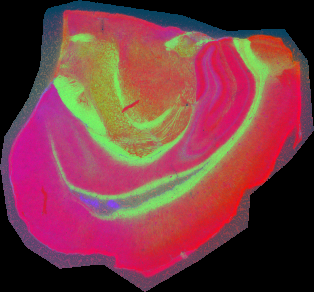

In [ ]:
from msi_visual.pca_3d import PCA3D
import time

t0 = time.time()

#mean_vector = np.median(img, axis=(0, 1), keepdims=True)
#modified = np.log1p(img + 1e-6)

pca_viz = PCA3D())(img)
pca_viz[img.max(axis=-1) == 0] = 0
print(time.time() - t0)
display(Image.fromarray(pca_viz))

In [109]:
from msi_visual.percentile_ratio import TOP3
import importlib
import msi_visual
importlib.reload(msi_visual.percentile_ratio)
import time
import numba
import numpy as np
import cv2

import numpy as np
import cv2

class TOP3Optimized:
    def __init__(self, low=99.9, norm_percentile=99.9):
        self.low = low
        self.norm_percentile = norm_percentile

    def __repr__(self):
        return f"TOP-3 Intensities. low={self.low}"


    def __call__(self, img: np.ndarray, power=1, to_lab=True):
        @numba.njit(parallel=True, fastmath=True)
        def get_p0p1p2(img):
            H, W, C = img.shape
            flat = img.reshape(-1, C)
            N = flat.shape[0]

            # Allocate output arrays
            p0 = np.empty(N, dtype=np.float32)
            p1 = np.empty(N, dtype=np.float32)
            p2 = np.empty(N, dtype=np.float32)

            # Loop through each pixel and find the top 3 values
            for i in numba.prange(N):  # Parallelized loop
                row = flat[i]
                v0, v1, v2 = -np.inf, -np.inf, -np.inf

                for v in row:
                    if v > v0:
                        v2, v1, v0 = v1, v0, v  # Shift down
                    elif v > v1:
                        v2, v1 = v1, v
                    elif v > v2:
                        v2 = v
                
                p0[i], p1[i], p2[i] = v0, v1, v2
            p0, p1, p2 = p0.reshape(H, W), p1.reshape(H, W), p2.reshape(H, W)
            return p0, p1, p2
        
        p0, p1, p2 = get_p0p1p2(img)
        if power != 1:
            p0 = np.power(p0, power)
            p1 = np.power(p1, power)
            p2 = np.power(p2, power)
        # Normalize
        percentiles = np.percentile([p0, p1, p2], self.norm_percentile, axis=(1, 2))

        p0 /= percentiles[0]
        p1 /= percentiles[1]
        p2 /= percentiles[2]

        # Clip to [0,1]
        np.clip(p0, 0, 1, out=p0)
        np.clip(p1, 0, 1, out=p1)
        np.clip(p2, 0, 1, out=p2)

        # p = np.concatenate( (p0[..., None], p1[..., None], p2[..., None]), axis=-1)
        # p = p / (1e-6 + np.sum(p, axis=-1)[..., None])
        # visualization = np.uint8(255 * p)


        # Merge into RGB
        visualization = cv2.merge([(np.uint8(255 * p0)), (np.uint8(255 * p1)), (np.uint8(255 * p2))])
        if to_lab:
            visualization = cv2.cvtColor(visualization, cv2.COLOR_LAB2RGB)
        visualization[p0  == 0] = 0
        return visualization

In [4]:
import numpy as np
import numba

def get_correlations(img, thresholds, approximate=False):
    def get_correlation_groups(threshold):
        high_corr_indices = np.where(np.abs(correlation_matrix) > threshold)
        # Get unique pairs (avoiding duplicates since correlation matrix is symmetric)
        pairs = []
        for i, j in zip(*high_corr_indices):
            if i < j:  # Only take one of the symmetric pairs
                pairs.append((i, j, correlation_matrix[i,j]))
        groups = []
        for a, b, _ in pairs:
            found = False
            for g in groups:
                if a in g or b in g:
                    g.append(a)
                    g.append(b)
                    found = True
                    break
            if not found:
                groups.append([a, b])
        return [list(set(g)) for g in groups]
    
    vector = img.reshape(-1, img.shape[-1])
    t0 = time.time()
    mask = vector.max(axis=-1) > 0
    
    masked_vector = vector[mask]
    if approximate:
        max_vector  = masked_vector.max(axis=0)
        max_vector[max_vector == 0] = -1
        max_mask = vector > max_vector * 0.95
        filtered_vector = vector[max_mask.max(axis=-1) > 0]
        correlation_matrix = np.corrcoef(filtered_vector.T)
    else:
    # Calculate correlation matrix
        correlation_matrix = np.corrcoef(masked_vector[::4, :].T)
    # Set diagonal to 0 since we don't want self-correlations
    np.fill_diagonal(correlation_matrix, 0)
    results = {}
    for th in thresholds:
        groups = get_correlation_groups(th)
        results[th] = groups
    return results

def correlation_merging(img, groups):
    # Create a copy of the original image
    summed_img = img
    # For each group of indices in groups
    for group in groups:
        #print(group)
        group_sum = img[:,:,group].sum(axis=-1)
        # Replace the first index in the group with the sum
        # and zero out the rest of the indices in that group
        #print(group[0])
        summed_img[:,:,group[0]] = group_sum
        summed_img[:,:,group[1 : ]] = 0   
    #summed_img = summed_img / (1e-7 + summed_img.sum(axis=-1, keepdims=True))
    return summed_img


img = get_img(1)
t0 = time.time()
groups = get_correlations(img, thresholds=[0.9, 0.7, 0.3], approximate=False)
merged = img
images = []


viz = TOP3Optimized()(img, 1)
images.append(viz)
for th in groups:
    merged = correlation_merging(merged, groups[th])
    for p in [1, 0.8]:
        viz = TOP3Optimized()(merged, p)
        images.append(viz)
        #display(Image.fromarray(viz))

print("Total Took", time.time() - t0)

c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Total Took 127.95965218544006


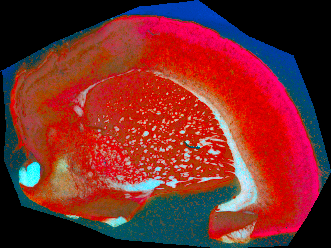

zadu took 3.8855552673339844
1.7857747077941895 trustwo
{'Saliency Δ=20% gamma=0': 0.8042, 'Smoothness Δ=20% gamma=0': 0.8674, 'Saliency Δ=30% gamma=0': 0.9172, 'Smoothness Δ=30% gamma=0': 0.9388, 'Saliency Δ=10% gamma=0': 0.6276, 'Smoothness Δ=10% gamma=0': 0.7362, 'Avg. Saliency gamma=0': 0.783, 'Avg. Smoothness gamma=0': 0.8474666666666666, 'Saliency Δ=20% gamma=2.0': 0.7652398895833477, 'Smoothness Δ=20% gamma=2.0': 0.9354875795443851, 'Saliency Δ=30% gamma=2.0': 0.8990486748154808, 'Smoothness Δ=30% gamma=2.0': 0.9742803502253254, 'Saliency Δ=10% gamma=2.0': 0.5571027336352923, 'Smoothness Δ=10% gamma=2.0': 0.8401724419759584, 'Avg. Saliency gamma=2.0': 0.7404637660113735, 'Avg. Smoothness gamma=2.0': 0.9166467905818897, 'Correlation Cosine': 0.5310482638949354, 'Correlation L-∞': 0.737030149466545, 'Spearman Cosine': 0.7979203896096299, 'Spearman L-∞': 0.8008000575400732, 'mrre_false': 0.8593855094379569, 'mrre_missing': 0.9187736177519237, 'lcmc': 0.4250498998998999, 'Trustworth

In [9]:
from msi_visual.metrics import MSIVisualizationMetrics
import importlib
importlib.reload(msi_visual.metrics)
from msi_visual.metrics import MSIVisualizationMetrics

#img = get_img(1)

viz = np.uint8(np.median(images[ : -4], axis=0))
display(Image.fromarray(viz))

# for a in images:
#     display(Image.fromarray(a))
#viz = images[0]
metrics = MSIVisualizationMetrics(
    img, viz, num_samples=5000).get_metrics()
print(metrics)


In [64]:
pca_metrics = MSIVisualizationMetrics(
    img, pca_viz, num_samples=5000).get_metrics()


zadu took 3.7625083923339844
1.777358055114746 trustwo


In [65]:
pca_metrics

{'Saliency Δ=20% gamma=0': 0.8098,
 'Smoothness Δ=20% gamma=0': 0.942,
 'Saliency Δ=30% gamma=0': 0.8882,
 'Smoothness Δ=30% gamma=0': 0.9832,
 'Saliency Δ=10% gamma=0': 0.7002,
 'Smoothness Δ=10% gamma=0': 0.8618,
 'Avg. Saliency gamma=0': 0.7994,
 'Avg. Smoothness gamma=0': 0.9289999999999999,
 'Saliency Δ=20% gamma=2.0': 0.698002899559482,
 'Smoothness Δ=20% gamma=2.0': 0.9740841115168627,
 'Saliency Δ=30% gamma=2.0': 0.8085076635484963,
 'Smoothness Δ=30% gamma=2.0': 0.9927729270504263,
 'Saliency Δ=10% gamma=2.0': 0.6098256976344214,
 'Smoothness Δ=10% gamma=2.0': 0.9156911733661667,
 'Avg. Saliency gamma=2.0': 0.7054454202474666,
 'Avg. Smoothness gamma=2.0': 0.9608494039778185,
 'Correlation Cosine': 0.7107675587334787,
 'Correlation L-∞': 0.6209698121600371,
 'Spearman Cosine': 0.9280230170385437,
 'Spearman L-∞': 0.7462695237032915,
 'mrre_false': 0.9602057996546399,
 'mrre_missing': 0.9773296400239166,
 'lcmc': 0.6625998998998999,
 'Trustworthiness': 0.9741998116539141,
 'Tru

In [28]:
from msi_visual.percentile_ratio import TOP3
import importlib
import msi_visual
importlib.reload(msi_visual.percentile_ratio)
import time
import numba
import numpy as np
import cv2

import numpy as np
import cv2

class TOP3MZOptimized:
    def __init__(self, low=99.9, norm_percentile=99.9):
        self.low = low
        self.norm_percentile = norm_percentile

    def __repr__(self):
        return f"TOP-3 Intensities. low={self.low}"


    def __call__(self, img: np.ndarray, power=1):
        @numba.njit(parallel=True, fastmath=True)
        def get_p0p1p2(img):
            H, W, C = img.shape
            flat = img.reshape(-1, C)
            N = flat.shape[0]

            # Allocate output arrays for indices
            i0 = np.empty(N, dtype=np.int32)
            i1 = np.empty(N, dtype=np.int32)
            i2 = np.empty(N, dtype=np.int32)

            # Loop through each pixel and find indices of top 3 values
            for i in numba.prange(N):  # Parallelized loop
                row = flat[i]
                v0, v1, v2 = -np.inf, -np.inf, -np.inf
                idx0, idx1, idx2 = -1, -1, -1

                for j, v in enumerate(row):
                    if v > v0:
                        v2, v1, v0 = v1, v0, v  # Shift values down
                        idx2, idx1, idx0 = idx1, idx0, j  # Shift indices down
                    elif v > v1:
                        v2, v1 = v1, v
                        idx2, idx1 = idx1, j
                    elif v > v2:
                        v2 = v
                        idx2 = j
                
                i0[i], i1[i], i2[i] = idx0, idx1, idx2
            i0, i1, i2 = i0.reshape(H, W), i1.reshape(H, W), i2.reshape(H, W)
            return i0, i1, i2
        
        
        p0, p1, p2 = get_p0p1p2(img)
        return cv2.merge([p0, p1, p2])
        if power != 1:
            p0 = np.power(p0, power)
            p1 = np.power(p1, power)
            p2 = np.power(p2, power)
        # Normalize
        percentiles = np.percentile([p0, p1, p2], self.norm_percentile, axis=(1, 2))

        p0 /= percentiles[0]
        p1 /= percentiles[1]
        p2 /= percentiles[2]

        # Clip to [0,1]
        np.clip(p0, 0, 1, out=p0)
        np.clip(p1, 0, 1, out=p1)
        np.clip(p2, 0, 1, out=p2)

        # p = np.concatenate( (p0[..., None], p1[..., None], p2[..., None]), axis=-1)
        # p = p / (1e-6 + np.sum(p, axis=-1)[..., None])
        # visualization = np.uint8(255 * p)


        # Merge into RGB
        visualization = cv2.merge([(np.uint8(255 * p0)), (np.uint8(255 * p1)), (np.uint8(255 * p2))])
        visualization = cv2.cvtColor(visualization, cv2.COLOR_LAB2RGB)
        visualization[p0  == 0] = 0
        return visualization
    
# Calculate correlation matrix
vector = img.reshape(-1, img.shape[-1])
mask = vector.max(axis=-1) > 0
masked_vector = vector[mask]    
correlation_matrix = np.corrcoef(masked_vector[::4, :].T)
print(correlation_matrix.shape)


# viz = TOP3MZOptimized()(img)
# print(viz.shape)
# #display(Image.fromarray(viz))

(5255, 5255)


c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\PahnkeLab\miniconda3\envs\maldi\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [42]:
import numpy as np
from sklearn.manifold import SpectralEmbedding

def correlation_hash(correlation_matrix):
    embedding = SpectralEmbedding(n_components=3, affinity='precomputed')
    hash_values = embedding.fit_transform(correlation_matrix)

    return (hash_values - np.min(hash_values)) / (np.max(hash_values) - np.min(hash_values))  # Normalize to [0,1]

np.fill_diagonal(correlation_matrix, 0)  # Zero out self-correlations  
correlation_matrix[np.isnan(correlation_matrix)] = 0
correlation_matrix = (1 + correlation_matrix) / 2
hash = correlation_hash(correlation_matrix)
print(hash)


[[0.55926393 0.43700114 0.43163453]
 [0.43892212 0.4281353  0.49492839]
 [0.49356954 0.43803133 0.34721798]
 ...
 [0.52566604 0.44916765 0.35986134]
 [0.52566604 0.44916765 0.35986134]
 [0.52566604 0.44916765 0.35986134]]


(292, 314, 3)


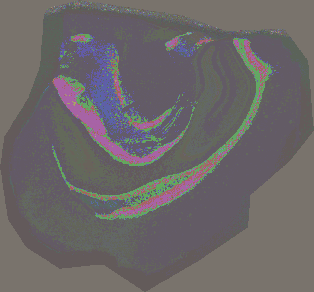

In [43]:
# Map hash values to visualization indices
viz_mapped = hash[viz]
viz_mapped = viz_mapped.mean(axis=-1)
print(viz_mapped.shape)
display(Image.fromarray(np.uint8(255 * viz_mapped)))


In [171]:
from sklearn.random_projection import GaussianRandomProjection
from msi_visual.utils import normalize
images = []
for power in [1, 3]:
    for _ in range(2):
        transformer = GaussianRandomProjection(n_components=3)
        result = transformer.fit_transform(np.power(vector, power))
        result = result.reshape(img.shape[0], img.shape[1], result.shape[-1])

        result = np.uint8(255 * normalize(result))
        result[img.max(axis=-1) == 0] = 0
        images.append(result)
        #display(Image.fromarray(result))

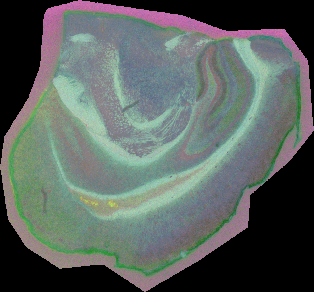

In [172]:
display(Image.fromarray(np.uint8(np.median(images, axis=0))))

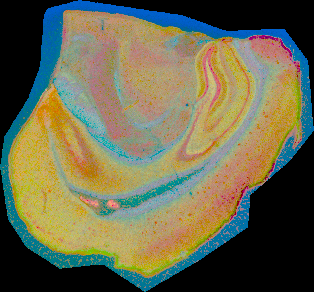

In [174]:
viz = TOP3Optimized()(img, to_lab=True)

viz2 = np.uint8(np.median(images, axis=0))
viz3 = viz**0.5 * viz2**0.5
viz3 = viz3 / viz3.max()
viz3 = np.uint8(255 *viz3)

display(Image.fromarray(viz3))

In [175]:
from msi_visual.metrics import MSIVisualizationMetrics
import importlib
importlib.reload(msi_visual.metrics)
from msi_visual.metrics import MSIVisualizationMetrics

metrics = MSIVisualizationMetrics(
    img, viz, num_samples=2000).get_metrics()
print(metrics)

metrics = MSIVisualizationMetrics(
    img, viz2, num_samples=2000).get_metrics()
print(metrics)

metrics = MSIVisualizationMetrics(
    img, viz3, num_samples=2000).get_metrics()
print(metrics)

zadu took 0.4192788600921631
0.29378318786621094 trustwo
{'Saliency Δ=20% gamma=0': 0.8205, 'Smoothness Δ=20% gamma=0': 0.849, 'Saliency Δ=30% gamma=0': 0.902, 'Smoothness Δ=30% gamma=0': 0.918, 'Saliency Δ=10% gamma=0': 0.6665, 'Smoothness Δ=10% gamma=0': 0.7205, 'Avg. Saliency gamma=0': 0.7963333333333334, 'Avg. Smoothness gamma=0': 0.8291666666666667, 'Saliency Δ=20% gamma=2.0': 0.7736435168141023, 'Smoothness Δ=20% gamma=2.0': 0.942015716085971, 'Saliency Δ=30% gamma=2.0': 0.8664429647552003, 'Smoothness Δ=30% gamma=2.0': 0.9777213575166928, 'Saliency Δ=10% gamma=2.0': 0.6027562029109887, 'Smoothness Δ=10% gamma=2.0': 0.8547170201452635, 'Avg. Saliency gamma=2.0': 0.7476142281600971, 'Avg. Smoothness gamma=2.0': 0.9248180312493091, 'Correlation Cosine': 0.5252235523418878, 'Correlation L-∞': 0.8869494011770809, 'Spearman Cosine': 0.7038440562871564, 'Spearman L-∞': 0.8638538703021053, 'mrre_false': 0.824113744584897, 'mrre_missing': 0.8861084526430796, 'lcmc': 0.3616984335839599, '

In [141]:
metrics = MSIVisualizationMetrics(
    img, viz3, num_samples=5000).get_metrics()
print(metrics)

zadu took 3.752871513366699
1.7662291526794434 trustwo
{'Saliency Δ=20% gamma=0': 0.7206, 'Smoothness Δ=20% gamma=0': 0.8042, 'Saliency Δ=30% gamma=0': 0.8198, 'Smoothness Δ=30% gamma=0': 0.8832, 'Saliency Δ=10% gamma=0': 0.5934, 'Smoothness Δ=10% gamma=0': 0.687, 'Avg. Saliency gamma=0': 0.7112666666666666, 'Avg. Smoothness gamma=0': 0.7914666666666667, 'Saliency Δ=20% gamma=2.0': 0.6404183510711922, 'Smoothness Δ=20% gamma=2.0': 0.8990038639807285, 'Saliency Δ=30% gamma=2.0': 0.7512321471497729, 'Smoothness Δ=30% gamma=2.0': 0.9519943397621845, 'Saliency Δ=10% gamma=2.0': 0.509455928699779, 'Smoothness Δ=10% gamma=2.0': 0.8023817235073133, 'Avg. Saliency gamma=2.0': 0.6337021423069147, 'Avg. Smoothness gamma=2.0': 0.8844599757500755, 'Correlation Cosine': 0.7626284110170343, 'Correlation L-∞': 0.5982795365273161, 'Spearman Cosine': 0.6164262551427784, 'Spearman L-∞': 0.5563597361106231, 'mrre_false': 0.7724862790883776, 'mrre_missing': 0.806721590074171, 'lcmc': 0.2386998998998999, '